# Figure XX - Single cell GFP distributions
Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Infected at 6-well scale \
Reseed at 20k/well into antibiotic conditions \
Media change every other day \
Flow on 6 dpi \



Reps:
- 2026.06.03: 3 reps


In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.patches import Patch

## Load Data

In [2]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.03_exp47': ['Plate1', 'Plate2', 'Plate3', 'Plate4']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'Figure_XX_single_cells'
cache_path = rd.rootdir/'output'/'Figure_XX_single_cells'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [3]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'mRuby2-A', 'mRuby2-H','TagBFP-A', 'TagBFP-H']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [4]:
data['conds'] = data['reporter'] +'.'+ data['Puro'] 
display(data)

,reporter,Puro,Puro#,Date,well,population,FSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,TagBFP-A,TagBFP-H,mRuby2-A,mRuby2-H,conds
0,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,239937,114.0,89.0,20199.0,17256.0,51.0,84.0,90.0,186.0,pKG05002.10x
1,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,420539,-78.0,80.0,17792.0,13077.0,-14.0,58.0,-66.0,70.0,pKG05002.10x
2,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,360555,66680.0,48986.0,46504.0,37146.0,570.0,381.0,23058.0,17791.0,pKG05002.10x
3,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,303230,67.0,50.0,10007.0,8310.0,255.0,141.0,167.0,204.0,pKG05002.10x
4,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,288188,78.0,63.0,17562.0,14627.0,155.0,151.0,225.0,235.0,pKG05002.10x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23010622,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,368281,63.0,87.0,-17.0,58.0,39.0,147.0,25.0,107.0,Untransfected.0x
23010623,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,442954,65.0,143.0,73.0,105.0,265.0,113.0,136.0,156.0,Untransfected.0x
23010624,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,486336,76.0,85.0,91.0,80.0,275.0,141.0,107.0,90.0,Untransfected.0x
23010625,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,390673,97.0,88.0,105.0,74.0,99.0,96.0,171.0,171.0,Untransfected.0x


In [5]:
untransfected = data[data['reporter'] == 'Untransfected']

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\1433429232.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\1433429232.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(untransfected, x=param,hue='reporter

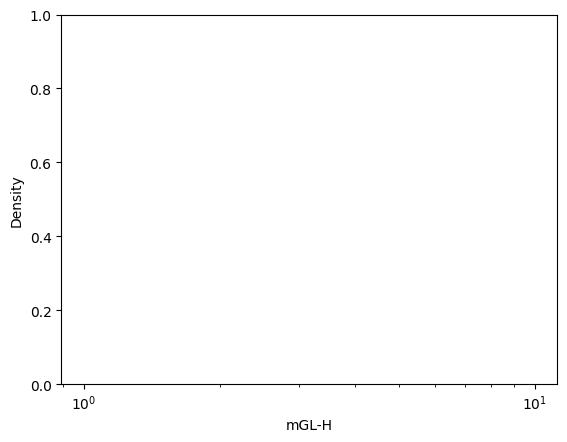

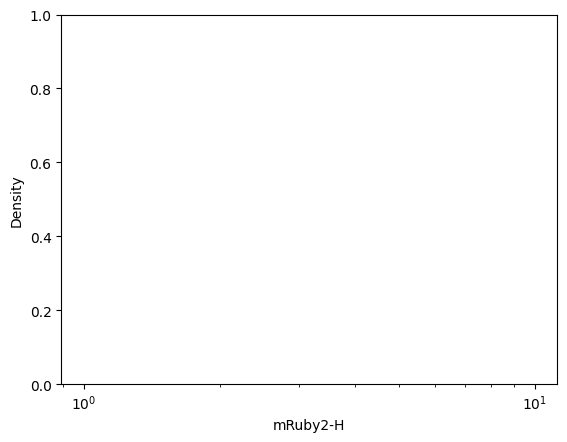

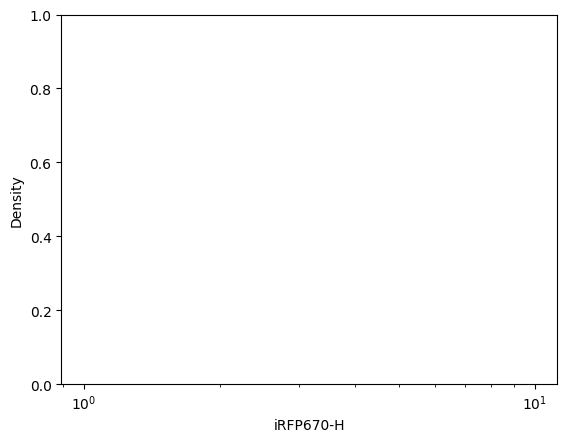

In [6]:
parameters = np.array(['mGL-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [7]:
iRFP670_H_thresh = 2.5e2
eGFP_gate = 8000

In [8]:
data = data[(data['reporter'] != 'pKG04437.Controls') & (data['reporter'] != 'pKG05003.Controls')]

## Gating cells

**Gate for infected cells**

In [9]:
# Categorize cells based on iRFP670_thresh
data.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data.loc[(data['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'reporter', 'conds', 'Date', 'Puro']
count_df_reps = data.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

## Histograms

**Single cell distributions of DASIT selection on eGFP population**

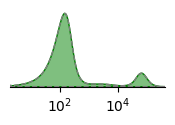

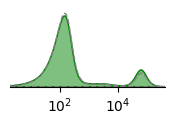

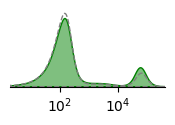

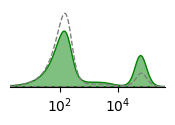

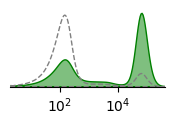

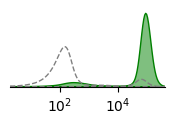

In [12]:
reporters = ['pKG05002']
parameters = pd.array(['mGL-A', 'TagBFP-A'])
plottitle = np.array(['0x_5002.svg', '2_5x_5002.svg', '5x_5002.svg', '10x_5002.svg', '20x_5002.svg', '40x_5002.svg'])
puro = np.array(['0x', '2.5x', '5x', '10x', '20x', '40x'])

xsize = 2; ysize = 1; figsize = (xsize, ysize)
untransfected = data[data['reporter'] == 'Untransfected']
for j in range(6):
    plt.figure(figsize=figsize)
    underlay = data[(data['reporter'] == 'pKG05002') & (data['Puro'] == '0x')]
    data_now = data[(data['reporter'] == reporters[0]) & (data['Puro']==puro[j])]
    g = sns.kdeplot(data=data_now, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0.5,common_norm=False,palette=['green'])
    g = sns.kdeplot(data=underlay, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0,common_norm=False,palette=['grey'], linestyle = '--')
    g.spines['left'].set_visible(False)
    plt.gca().get_yaxis().set_visible(False)
    plt.gca().set_xlabel("")
    g.set_xlim(xmin=2, xmax=400000)
    g.spines['top'].set_visible(False)
    g.spines['right'].set_visible(False)
    g = g.get_figure()
    g.savefig(rd.outfile(output_path/plottitle[j]),bbox_inches='tight')

## Bar plots

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\164871436.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf val

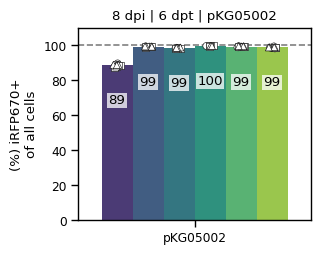

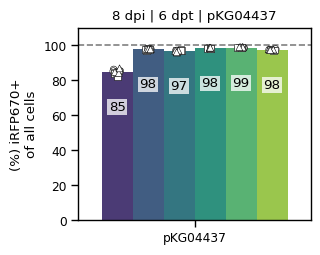

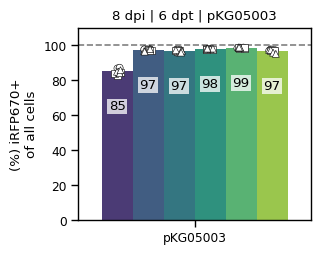

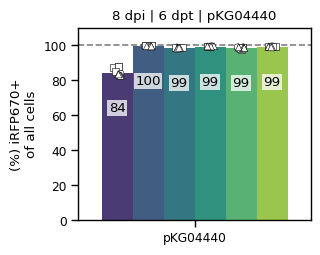

In [37]:
# General plotting params
x = 'reporter'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

antibiotic_map = {'pKG04437':'Puro', 'pKG04440':'Puro','pKG05003':'Puro','pKG05002':'Puro'}


for reporter in data.reporter.unique():

    if (reporter=='Untransfected'): continue

    curr_df = data_iRFP670_percent_reps[data_iRFP670_percent_reps.reporter == reporter]

    hue = antibiotic_map[reporter]
    hue_order = np.sort(curr_df[hue].unique())

    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

    # Plot
    sns.barplot(
        ax=ax, data=curr_df,
        x=x, y=y, ci=None, hue=hue,
        palette="viridis", alpha=1)
    
    # Plot tech reps
    for (j, Date) in enumerate(curr_df.Date.unique()):
        sns.stripplot(
            ax=ax, data=curr_df[(curr_df.Date == Date)],
            x=x, y=y, hue=hue,
            dodge=True, marker=marker_list[j],
            palette={puro:'white' for puro in hue_order}, size=5,
            edgecolor='black', linewidth=0.4)
        
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    # Formatting
    ax.yaxis.set_label_text('(%) iRFP670+\nof all cells')
    ax.set_ylim((0, 110))
    # h,l = ax.get_legend_handles_labels()
    # sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
    #     title=f'{hue} conc. [µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    # Title
    ax.set_title(f'8 dpi | 6 dpt | {reporter}')
    ax.axhline(100, 0, 1, color='grey', linestyle='--')
    ax.set_xlabel('')
    # Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-30)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
    # 
    # plt.savefig(figpath + f'bar_iRFP670-percent_{cond}.svg', bbox_inches='tight')

**EGFP Threshold**

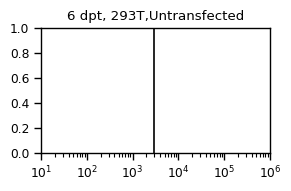

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Threshold for GFP
eGFP_H_thresh = 3*10**3

# Plot eGFP-H
x = 'mGL-H'

# Plot Ctrl-EGFP
cond = 'Untransfected'
sns.kdeplot(data=data.loc[(data['reporter'] == cond) & (data[x] > 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False), color='limegreen',
        fill=True)

# Plot neg ctrl
# sns.kdeplot(
#     data=untransfected,
#     ax=ax, x=x,
#     common_norm=False, log_scale=(True, False),
#     fill=False, linestyle='--', color='grey', legend=False)
# ax.annotate('Ctrl-\nneg', (0.3, 0.7), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'6 dpt, 293T,{cond}')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'dist-eGFP.svg', bbox_inches='tight')

**Gate for EGFP+ cells**

In [39]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'eGFP_cat'] = 'eGFP-'
data.loc[(data['mGL-H'] > eGFP_H_thresh), 'eGFP_cat'] = 'eGFP+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'reporter', 'conds', 'Date', 'Puro']
count_df_reps = df_infected.groupby([*group, 'well', 'eGFP_cat'])[
    'mGL-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_eGFP_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_eGFP_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'eGFP+')]
data_eGFP_count_reps = data_eGFP_count_reps.loc[(data_eGFP_count_reps['eGFP_cat'] == 'eGFP+')]

**Count total cells in each 96-well**

In [40]:
# Convert to dataframe
data_eGFP_count_reps = count_df_reps.reset_index()

# Calculate total cells per well
total_cells = (
    data_eGFP_count_reps
    .groupby([*group, 'well'])['count']
    .sum()
    .reset_index(name='total_cells')
)

# Add total_cells column
data_eGFP_count_reps = data_eGFP_count_reps.merge(
    total_cells,
    on=[*group, 'well'],
    how='left'
)

In [14]:
display(data_eGFP_count_reps)

,reporter,conds,Date,Puro,well,eGFP_cat,count,total_cells
0,pKG04437,pKG04437.0x,2026.06.03.x,0x,B1,eGFP+,4426,44940
1,pKG04437,pKG04437.0x,2026.06.03.x,0x,B1,eGFP-,40514,44940
2,pKG04437,pKG04437.0x,2026.06.03.x,0x,C1,eGFP+,4874,50529
3,pKG04437,pKG04437.0x,2026.06.03.x,0x,C1,eGFP-,45655,50529
4,pKG04437,pKG04437.0x,2026.06.03.x,0x,D1,eGFP+,4551,53200
...,...,...,...,...,...,...,...,...
567,pKG05003,pKG05003.5x,2026.06.03.xxx,5x,F9,eGFP-,40829,45560
568,pKG05003,pKG05003.5x,2026.06.03.xxx,5x,G9,eGFP+,2017,21838
569,pKG05003,pKG05003.5x,2026.06.03.xxx,5x,G9,eGFP-,19821,21838
570,pKG05003,pKG05003.5x,2026.06.03.xxx,5x,H9,eGFP+,1796,20267


**Conditions for plotting**

In [ ]:
Puro_conds = ['0x', '2.5x', '5x','10x','20x', '40x']

## eGFP+ Purity (%)

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\2078522879.py:40: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

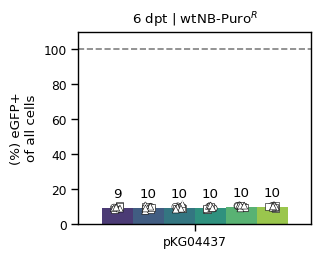

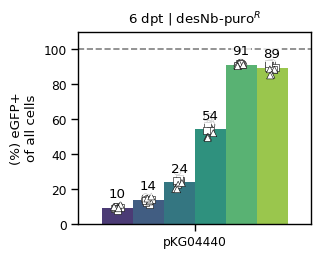

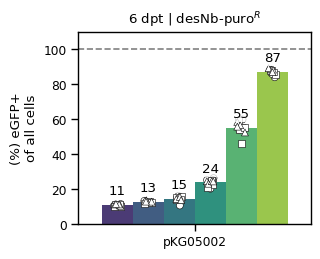

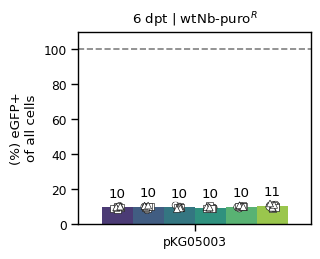

In [42]:
# General plotting params
x = 'reporter'
y = 'percent'
dpt = 6
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

antibiotic_map = {
    'pKG04437':'Puro',
    'pKG04440':'Puro',
    'pKG05003':'Puro',
    'pKG05002':'Puro'
}

label_map = {
    'pKG04437':'wtNB-Puro$^R$',
    'pKG04440':'desNb-puro$^R$',
    'pKG05003':'wtNb-puro$^R$',
    'pKG05002':'desNb-puro$^R$'
}


for cond in data_eGFP_percent_reps.reporter.unique():

    if cond == 'Untransfected':
        continue

    curr_df = data_eGFP_percent_reps.loc[
        (data_eGFP_percent_reps.reporter == cond)
    ]

    hue = antibiotic_map[cond]

    # enforce ordering based on Puro_conds
    hue_order = [p for p in Puro_conds if p in curr_df[hue].unique()]

    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

    # Bar plot
    sns.barplot(
        ax=ax,
        data=curr_df,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        ci=None,
        palette="viridis",
        alpha=1
    )

    # Plot tech reps
    for (j, date) in enumerate(curr_df.Date.unique()):

        sns.stripplot(
            ax=ax,
            data=curr_df[(curr_df.Date == date)],
            x=x,
            y=y,
            hue=hue,
            hue_order=hue_order,
            dodge=True,
            marker=marker_list[j],
            palette={puro: 'white' for puro in hue_order},
            size=5,
            edgecolor='black',
            linewidth=0.4,
        )

    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Formatting
    ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
    ax.set_ylim((0, 110))

    # Title
    ax.set_title(f'6 dpt | {label_map[cond]}')

    ax.axhline(100, 0, 1, color='grey', linestyle='--')

    ax.set_xlabel('')

    # Add barplot labels
    for sub_ax in plt.gcf().get_axes():

        for i in sub_ax.containers:

            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)

            for label in bar_labels:
                label.set_bbox(
                    dict(
                        facecolor='white',
                        alpha=0.75,
                        linewidth=0,
                        pad=1
                    )
                )

    # plt.savefig(figpath + f'bar_EGFP-percent_{cond}_{dpt}dpt.svg',
    #             bbox_inches='tight')

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\3473369180.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

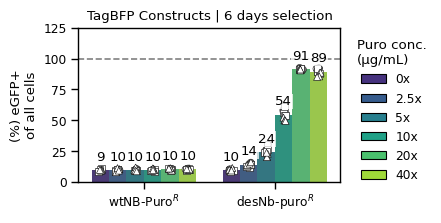

In [43]:
# General plotting params
x = 'reporter'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']

antibiotic_map = {
    'pKG04437':'Puro',
    'pKG04440':'Puro',
    'pKG05003':'Puro',
    'pKG05002':'Puro'
}

label_map = {
    'pKG04437':'wtNB-Puro$^R$',
    'pKG04440':'desNb-puro$^R$',
    'pKG05003':'wtNb-puro$^R$',
    'pKG05002':'desNb-puro$^R$'
}

df_curr = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.reporter == 'pKG04437') | (data_eGFP_percent_reps.reporter == 'pKG04440')]

hue = 'Puro'

# enforce ordering based on Puro_conds
hue_order = [p for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


# Plot tech reps
for (j, Date) in enumerate(df_curr.Date.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.Date == Date)],
        x=x, y=y, hue=hue, hue_order=hue_order,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro: 'white' for puro in hue_order},
        size=5,
        edgecolor='black',
        linewidth=0.4,
    )

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 125))

# Title
ax.set_title('TagBFP Constructs | 6 days selection')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'tagBFP_DASIT_puro.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\1431922886.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

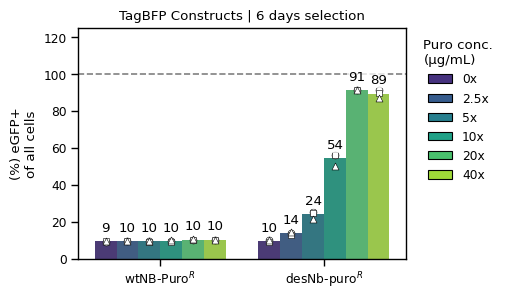

In [18]:
# General plotting params
x = 'reporter'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']

antibiotic_map = {
    'pKG04437':'Puro',
    'pKG04440':'Puro',
    'pKG05003':'Puro',
    'pKG05002':'Puro'
}

label_map = {
    'pKG04437':'wtNB-Puro$^R$',
    'pKG04440':'desNb-puro$^R$',
    'pKG05003':'wtNb-puro$^R$',
    'pKG05002':'desNb-puro$^R$'
}

df_curr = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.reporter == 'pKG04437') | (data_eGFP_percent_reps.reporter == 'pKG04440')]

hue = 'Puro'

# enforce ordering based on Puro_conds
hue_order = [p for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


bio_rep_means = (
    df_curr
    .groupby(['Date', x, hue], as_index=False)[y]
    .mean()
)

for j, Date in enumerate(bio_rep_means['Date'].unique()):
    sns.stripplot(
        ax=ax,
        data=bio_rep_means.query("Date == @Date"),
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=order,
        dodge=True,
        marker=marker_list[j],
        palette={p: 'white' for p in hue_order},
        size=5,  # larger since these are means
        edgecolor='black',
        linewidth=0.4,
    )

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 125))

# Title
ax.set_title('TagBFP Constructs | 6 days selection')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'tagBFP_DASIT_puro_means.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\1283760190.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

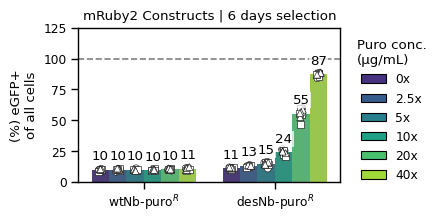

In [61]:
# General plotting params
x = 'reporter'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG05003', 'pKG05002']

antibiotic_map = {
    'pKG04437':'Puro',
    'pKG04440':'Puro',
    'pKG05003':'Puro',
    'pKG05002':'Puro'
}

label_map = {
    'pKG04437':'wtNb-Puro$^R$',
    'pKG04440':'desNb-puro$^R$',
    'pKG05003':'wtNb-puro$^R$',
    'pKG05002':'desNb-puro$^R$'
}

df_curr = data_eGFP_percent_reps.loc[(data_eGFP_percent_reps.reporter == 'pKG05003') | (data_eGFP_percent_reps.reporter == 'pKG05002')]

hue = 'Puro'

# enforce ordering based on Puro_conds
hue_order = [p for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


# Plot tech reps
for (j, Date) in enumerate(df_curr.Date.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.Date == Date)],
        x=x, y=y, hue=hue,hue_order=hue_order,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,)
    

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 125))

# Title
ax.set_title('mRuby2 Constructs | 6 days selection')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'mRuby2_DASIT_puro_eGFP_percent_both.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## eGFP+ cell counts

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\1820537367.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

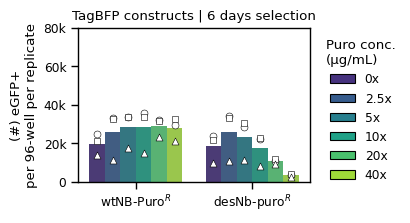

In [44]:
# General plotting params
x = 'reporter'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']

df_curr = data_eGFP_count_reps.loc[(data_eGFP_count_reps.reporter == 'pKG04437') | (data_eGFP_count_reps.reporter == 'pKG04440')]

hue = 'Puro'

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue, hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


bio_rep_means = (
    df_curr
    .groupby(['Date', x, hue], as_index=False)[y]
    .mean()
)

for j, Date in enumerate(bio_rep_means['Date'].unique()):
    sns.stripplot(
        ax=ax,
        data=bio_rep_means.query("Date == @Date"),
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=order,
        dodge=True,
        marker=marker_list[j],
        palette={p: 'white' for p in hue_order},
        size=5,  # larger since these are means
        edgecolor='black',
        linewidth=0.4,
    )


# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

 # Formatting
ax.yaxis.set_label_text('(#) eGFP+\nper 96-well per replicate')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 80e3))
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
#     title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    
# Title
ax.set_title(f'TagBFP constructs | 6 days selection')
ax.set_xlabel('')

plottitle = 'tagBFP_DASIT_puro_eGFP_cell_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Total cells

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\3035739686.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

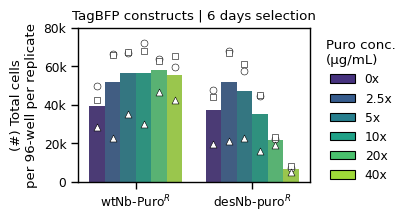

In [24]:
# General plotting params
x = 'reporter'
y = 'total_cells'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG04437', 'pKG04440']

df_curr = data_eGFP_count_reps.loc[(data_eGFP_count_reps.reporter == 'pKG04437') | (data_eGFP_count_reps.reporter == 'pKG04440')]

hue = 'Puro'

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue, hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


bio_rep_means = (
    df_curr
    .groupby(['Date', x, hue], as_index=False)[y]
    .mean()
)

for j, Date in enumerate(bio_rep_means['Date'].unique()):
    sns.stripplot(
        ax=ax,
        data=bio_rep_means.query("Date == @Date"),
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=order,
        dodge=True,
        marker=marker_list[j],
        palette={p: 'white' for p in hue_order},
        size=5,  # larger since these are means
        edgecolor='black',
        linewidth=0.4,
    )


# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

 # Formatting
ax.yaxis.set_label_text('(#) Total cells\nper 96-well per replicate')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 80e3))
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
#     title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    
# Title
ax.set_title(f'TagBFP constructs | 6 days selection')
ax.set_xlabel('')

plottitle = 'tagBFP_DASIT_puro_total_cell_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_19664\1444817787.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

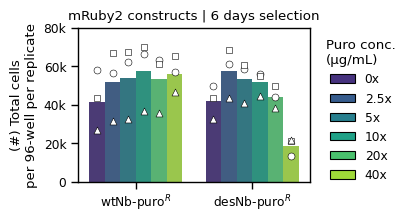

In [22]:
# General plotting params
x = 'reporter'
y = 'total_cells'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['pKG05003', 'pKG05002']

df_curr = data_eGFP_count_reps.loc[(data_eGFP_count_reps.reporter == 'pKG05002') | (data_eGFP_count_reps.reporter == 'pKG05003')]

hue = 'Puro'

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue, hue_order=hue_order,
    order=order,
    palette="viridis", alpha=1)


bio_rep_means = (
    df_curr
    .groupby(['Date', x, hue], as_index=False)[y]
    .mean()
)

for j, Date in enumerate(bio_rep_means['Date'].unique()):
    sns.stripplot(
        ax=ax,
        data=bio_rep_means.query("Date == @Date"),
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=order,
        dodge=True,
        marker=marker_list[j],
        palette={p: 'white' for p in hue_order},
        size=5,  # larger since these are means
        edgecolor='black',
        linewidth=0.4,
    )



# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

 # Formatting
ax.yaxis.set_label_text('(#) Total cells\nper 96-well per replicate')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 80e3))
# h,l = ax.get_legend_handles_labels()
# sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
#     title=f'Puro conc.\n[µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    
# Title
ax.set_title(f'mRuby2 constructs | 6 days selection')
ax.set_xlabel('')


plottitle = 'mRuby2_DASIT_puro_total_cell_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')